# Statistical Analysis (Extended): Final Experiment — Does the Tail Help Reorientation?

**Goal:** Test if the tail (With Tail vs No Tail) affects reorientation performance in the final drop-test experiment.

**Data:** `report_final.csv`, produced by `data_analysis_final.py` from `telemetry/Final_Experiment/`. Fall-duration/distance filtering, the `0°-pitch`/`180°-roll` de-dup, and the spare-rep exclusion are already applied upstream — this notebook starts from the cleaned per-drop report.

**Problem:** Initial conditions (angles and velocities at release) vary randomly due to drop rig imprecision.

**Solution:** OLS regression controlling for trial condition and initial-condition variability (mirrors `stats_final.py`, expanded here for interactive exploration).

**Measurement:** Front IMU only.

**Conditions:** 3 roll magnitudes (`r45`, `r90`, `r180`) + 3 combined roll180+pitch conditions (`r180_p15`, `r180_p30`, `r180_p45`).

**Outcomes:** |Roll angle|, |Roll rate|, |Pitch angle|, |Pitch rate| at 2.5 m — absolute values, since deviation from upright in either direction is equally bad.

No cell outputs are pre-computed in this file — run all cells to populate plots/output.

**v2 note:** this is the extended version. Sections 1–10 are identical to `stats_final.ipynb` (load data, diagnostics, main model with HC3, corrected per-trial tests, precision-framed power) and were the **primary, pre-specified analysis**. Sections 11–16 are **exploratory / post-hoc**: they were written after looking at the Sections 1–10 results, to stress-test them from angles a reviewer would raise (residual assumptions, variance not just mean, equivalence framing, an outcome-definition check, an exclusion-rule audit) — not analyses that were planned in advance. That distinction matters for how much weight any single result there should carry, especially the one below that changes the picture rather than just reinforcing it (Section 15).

---


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Condition ordering used throughout (roll sweep, then pitch sweep) instead of alphabetical
ROLL_CONDITION_ORDER  = ['r45', 'r90', 'r180']
PITCH_CONDITION_ORDER = ['r180_p15', 'r180_p30', 'r180_p45']
CONDITION_ORDER       = ROLL_CONDITION_ORDER + PITCH_CONDITION_ORDER

MORPHOLOGIES = ['With Tail', 'No Tail']

# Bonferroni correction used in Section 6: the per-trial loop there tests all 4 outcomes
# (roll angle, roll rate, pitch angle, pitch rate) at each of the 6 trial conditions —
# 6 x 4 = 24 independent t-tests, so that's the correction factor (not the 3x2+3x2=12 pairing
# used in the older stats_mbc.py, which only tested each condition against its "native" outcome).
N_COMPARISONS = 24


## 1. Load Data and Create Variables

In [2]:
df = pd.read_csv('report_final.csv', dtype={'date': str})

print(f"Total drops: {len(df)}")
print(f"Morphologies: {df['morphology'].unique()}")
print(f"Trials: {df['trial'].unique()}")
print(f"\nDrops per morphology x trial:")
print(pd.crosstab(df['morphology'], df['trial'])[CONDITION_ORDER])


Total drops: 72
Morphologies: ['With Tail' 'No Tail']
Trials: ['r180' 'r45' 'r90' 'r180_p15' 'r180_p30' 'r180_p45']

Drops per morphology x trial:
trial       r45  r90  r180  r180_p15  r180_p30  r180_p45
morphology                                              
No Tail       6    7     6         6         6         6
With Tail     6    5     6         6         6         6


In [3]:
# Front IMU only, with angle wrapping fix
#
# IMPORTANT: F_roll values can exceed ±180° due to np.unwrap() in the processing pipeline.
# Taking abs() of 355° would give 355°, but physically that's only 5° from upright.
# We use shortest angular distance instead: wrap to [-180, 180], then abs().

def angular_distance(angle):
    '''Shortest angular distance from 0. Handles wrapped angles correctly.'''
    return np.abs(((angle + 180) % 360) - 180)

def wrap_angle(angle):
    '''Wrap signed angle to [-180, 180].'''
    return ((angle + 180) % 360) - 180

# Outcomes: shortest angular distance from upright
df['abs_roll_2p5m']      = angular_distance(df['F_roll_2p5m'])
df['abs_pitch_2p5m']     = angular_distance(df['F_pitch_2p5m'])
df['abs_rollrate_2p5m']  = df['F_rollrate_2p5m'].abs()  # rates don't wrap
df['abs_pitchrate_2p5m'] = df['F_pitchrate_2p5m'].abs()

# Initial conditions: wrap angles, keep rates signed
df['roll_initial']      = wrap_angle(df['F_roll_initial'])
df['pitch_initial']     = wrap_angle(df['F_pitch_initial'])
df['rollrate_initial']  = df['F_rollrate_initial']
df['pitchrate_initial'] = df['F_pitchrate_initial']

print(f"Roll outcome range: [{df['abs_roll_2p5m'].min():.1f}, {df['abs_roll_2p5m'].max():.1f}] (should be ≤ 180)")
print(f"Pitch outcome range: [{df['abs_pitch_2p5m'].min():.1f}, {df['abs_pitch_2p5m'].max():.1f}] (should be ≤ 180)")
df[['morphology', 'trial', 'abs_roll_2p5m', 'abs_rollrate_2p5m', 'abs_pitch_2p5m', 'abs_pitchrate_2p5m']].head(10)


Roll outcome range: [0.2, 60.2] (should be ≤ 180)
Pitch outcome range: [0.0, 47.1] (should be ≤ 180)


,morphology,trial,abs_roll_2p5m,abs_rollrate_2p5m,abs_pitch_2p5m,abs_pitchrate_2p5m
0,With Tail,r180,12.12,54.42,34.63,105.32
1,With Tail,r180,6.91,8.73,9.08,32.72
2,With Tail,r180,35.60,62.76,0.66,103.36
3,With Tail,r180,18.58,35.63,11.35,93.12
4,With Tail,r180,14.49,7.62,10.42,83.51
5,With Tail,r180,6.84,186.77,26.04,23.25
6,With Tail,r45,6.36,71.46,9.16,188.68
7,With Tail,r45,5.13,70.48,5.43,43.94
8,With Tail,r45,14.34,39.93,19.84,369.48
9,With Tail,r45,18.52,60.03,0.90,4.08


## 2. Diagnostic Checks: Confounds and Blocking

**Question A — within-condition imbalance:** does tail presence systematically affect initial conditions, controlling for trial?

**Method:** Two-way ANOVA: `Initial_Condition ~ Morphology + Trial`. p > 0.05 → no detectable imbalance; p < 0.05 → flagged.

Four non-significant tests is *absence of evidence*, not evidence of absence — treat "no detectable imbalance" as a weaker claim than "confirmed random," especially for any variable close to the 0.05 threshold. The model in Section 4 adjusts for these covariates regardless, so causal interpretation doesn't hinge entirely on this check passing.

**Question B — collection-date blocking:** the two morphologies were not collected in a randomized interleaved order — they're unevenly split across the three collection dates. If anything drifted day-to-day (battery, rig calibration, joint wear), it could load onto the morphology coefficient. This is checked directly below by adding `C(date)` to the model and seeing whether the tail coefficient moves.

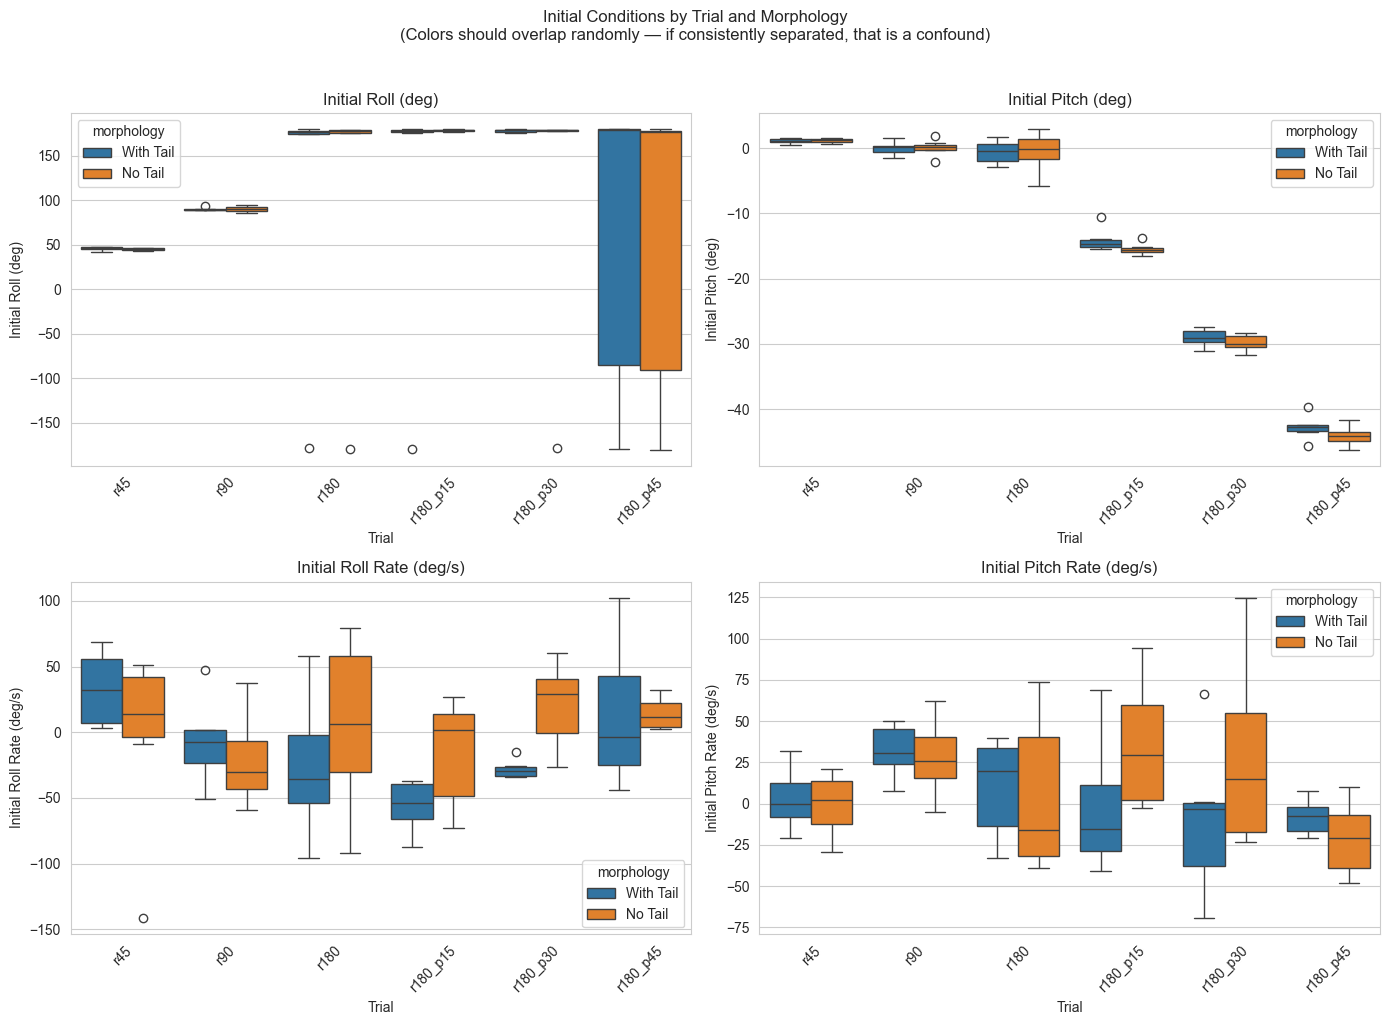

In [4]:
# Visualize initial conditions by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

initial_vars = [
    ('roll_initial',      'Initial Roll (deg)'),
    ('pitch_initial',     'Initial Pitch (deg)'),
    ('rollrate_initial',  'Initial Roll Rate (deg/s)'),
    ('pitchrate_initial', 'Initial Pitch Rate (deg/s)')
]

for idx, (var, label) in enumerate(initial_vars):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx], order=CONDITION_ORDER)
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Initial Conditions by Trial and Morphology\n(Colors should overlap randomly — if consistently separated, that is a confound)', y=1.02)
plt.tight_layout()
plt.show()


In [5]:
# Two-way ANOVA: Initial_Condition ~ Morphology + Trial
print("="*80)
print("DIAGNOSTIC A: Does tail presence affect initial conditions (controlling for trial)?")
print("="*80)

diagnostic_results = []
confound_flags = {}  # var -> bool, reused in Section 4/6 to flag caution on ANY outcome, not just the matched one

for var, label in initial_vars:
    model = smf.ols(f"{var} ~ C(morphology) + C(trial)", data=df).fit()
    anova_table = anova_lm(model, typ=2)

    morph_f = anova_table.loc['C(morphology)', 'F']
    morph_p = anova_table.loc['C(morphology)', 'PR(>F)']
    is_confounded = morph_p < 0.05
    result  = "✅ no detectable imbalance" if not is_confounded else "⚠️ CONFOUNDED"

    print(f"\n{label}")
    print(f"  Morphology effect: F = {morph_f:.3f}, p = {morph_p:.4f} → {result}")

    diagnostic_results.append({'Variable': label, 'F': morph_f, 'p-value': morph_p, 'Result': result})
    confound_flags[var] = is_confounded

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(pd.DataFrame(diagnostic_results).to_string(index=False))
print("\nNote: roll and pitch are mechanically coupled (Kane-Scher effect), so a confound in one")
print("initial variable can leak into an outcome it isn't nominally paired with. Section 4 checks")
print("outcome models against ALL flagged initial variables, not only the matching one.")


DIAGNOSTIC A: Does tail presence affect initial conditions (controlling for trial)?

Initial Roll (deg)
  Morphology effect: F = 0.000, p = 0.9970 → ✅ no detectable imbalance

Initial Pitch (deg)
  Morphology effect: F = 2.140, p = 0.1483 → ✅ no detectable imbalance

Initial Roll Rate (deg/s)
  Morphology effect: F = 1.340, p = 0.2513 → ✅ no detectable imbalance

Initial Pitch Rate (deg/s)
  Morphology effect: F = 1.052, p = 0.3088 → ✅ no detectable imbalance

SUMMARY
                  Variable        F  p-value                    Result
        Initial Roll (deg) 0.000014 0.997021 ✅ no detectable imbalance
       Initial Pitch (deg) 2.139804 0.148339 ✅ no detectable imbalance
 Initial Roll Rate (deg/s) 1.339559 0.251347 ✅ no detectable imbalance
Initial Pitch Rate (deg/s) 1.052123 0.308821 ✅ no detectable imbalance

Note: roll and pitch are mechanically coupled (Kane-Scher effect), so a confound in one
initial variable can leak into an outcome it isn't nominally paired with. Section 4

In [6]:
# DIAGNOSTIC B: collection-date blocking check
print("="*80)
print("DIAGNOSTIC B: Is morphology confounded with collection date?")
print("="*80)
print(pd.crosstab(df['date'], df['morphology']))
print()

MORPH_TERM  = 'C(morphology, Treatment(reference="No Tail"))'
MORPH_PARAM = f'{MORPH_TERM}[T.With Tail]'
FORMULA_BASE = f"{MORPH_TERM} + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"

print("Sensitivity check: does adding C(date) move the tail coefficient?")
print("-" * 80)
for var, label in [('abs_roll_2p5m', '|Roll Angle|'), ('abs_rollrate_2p5m', '|Roll Rate|')]:
    m_base = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df).fit()
    m_date = smf.ols(f"{var} ~ {FORMULA_BASE} + C(date)", data=df).fit()
    c_base, c_date = m_base.params[MORPH_PARAM], m_date.params[MORPH_PARAM]
    pct_change = (c_date - c_base) / abs(c_base) * 100

    ci_base = m_base.conf_int().loc[MORPH_PARAM]
    ci_date = m_date.conf_int().loc[MORPH_PARAM]
    ci_overlap = not (ci_date[1] < ci_base[0] or ci_date[0] > ci_base[1])

    print(f"{label}:")
    print(f"  without C(date): coef={c_base:+.2f}, 95% CI=[{ci_base[0]:.2f}, {ci_base[1]:.2f}], p={m_base.pvalues[MORPH_PARAM]:.4f}")
    print(f"  with C(date)   : coef={c_date:+.2f}, 95% CI=[{ci_date[0]:.2f}, {ci_date[1]:.2f}], p={m_date.pvalues[MORPH_PARAM]:.4f}")
    print(f"  → moved {pct_change:+.0f}% ({'same direction' if np.sign(c_base) == np.sign(c_date) else 'SIGN FLIPS — investigate'}, CIs {'overlap' if ci_overlap else 'do NOT overlap'})")
    print(f"  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.")
print()
print("Caveat: C(date) is highly collinear with C(trial) here (the pitch sweep only ran on 08/17,")
print("r45/r90 only on 08/10 and 08/16), so no adjustment can cleanly separate 'date effect' from")
print("'trial effect' — this is a genuine design limitation (imbalanced blocking), not something")
print("this sensitivity check resolves. It belongs in the limitations section as a design flaw.")


DIAGNOSTIC B: Is morphology confounded with collection date?
morphology  No Tail  With Tail
date                          
0810              6          9
0816             10         20
0817             21          6

Sensitivity check: does adding C(date) move the tail coefficient?
--------------------------------------------------------------------------------
|Roll Angle|:
  without C(date): coef=-4.13, 95% CI=[-9.84, 1.58], p=0.1536
  with C(date)   : coef=-5.62, 95% CI=[-12.91, 1.68], p=0.1287
  → moved -36% (same direction, CIs overlap)
  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.
|Roll Rate|:
  without C(date): coef=-37.31, 95% CI=[-87.57, 12.95], p=0.1429
  with C(date)   : coef=-44.15, 95% CI=[-108.11, 19.81], p=0.1724
  → moved -18% (same direction, CIs overlap)
  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.

Caveat: C(date) is highly collinear with C(trial

## 3. Descriptive Statistics: Outcomes at 2.5m

In [7]:
outcomes = [
    ('abs_roll_2p5m',      '|Roll Angle| at 2.5m (deg)'),
    ('abs_rollrate_2p5m',  '|Roll Rate| at 2.5m (deg/s)'),
    ('abs_pitch_2p5m',     '|Pitch Angle| at 2.5m (deg)'),
    ('abs_pitchrate_2p5m', '|Pitch Rate| at 2.5m (deg/s)')
]

for var, label in outcomes:
    print(f"\n{label}:")
    print(df.groupby('morphology')[var].describe()[['mean', 'std', 'min', 'max', 'count']])



|Roll Angle| at 2.5m (deg):
                 mean        std   min    max  count
morphology                                          
No Tail     16.471351  14.699796  0.20  60.15   37.0
With Tail   12.844571  10.237956  0.29  44.18   35.0

|Roll Rate| at 2.5m (deg/s):
                  mean         std   min     max  count
morphology                                             
No Tail     115.281351  133.780638  0.00  660.50   37.0
With Tail    81.477714   71.230129  6.66  313.52   35.0

|Pitch Angle| at 2.5m (deg):
                 mean        std   min    max  count
morphology                                          
No Tail     14.697297  13.074961  0.02  47.10   37.0
With Tail   14.266571  10.247845  0.53  37.12   35.0

|Pitch Rate| at 2.5m (deg/s):
                  mean         std   min     max  count
morphology                                             
No Tail     157.613784  139.437061  0.00  502.08   37.0
With Tail   170.578286  148.238560  4.08  524.78   35.0


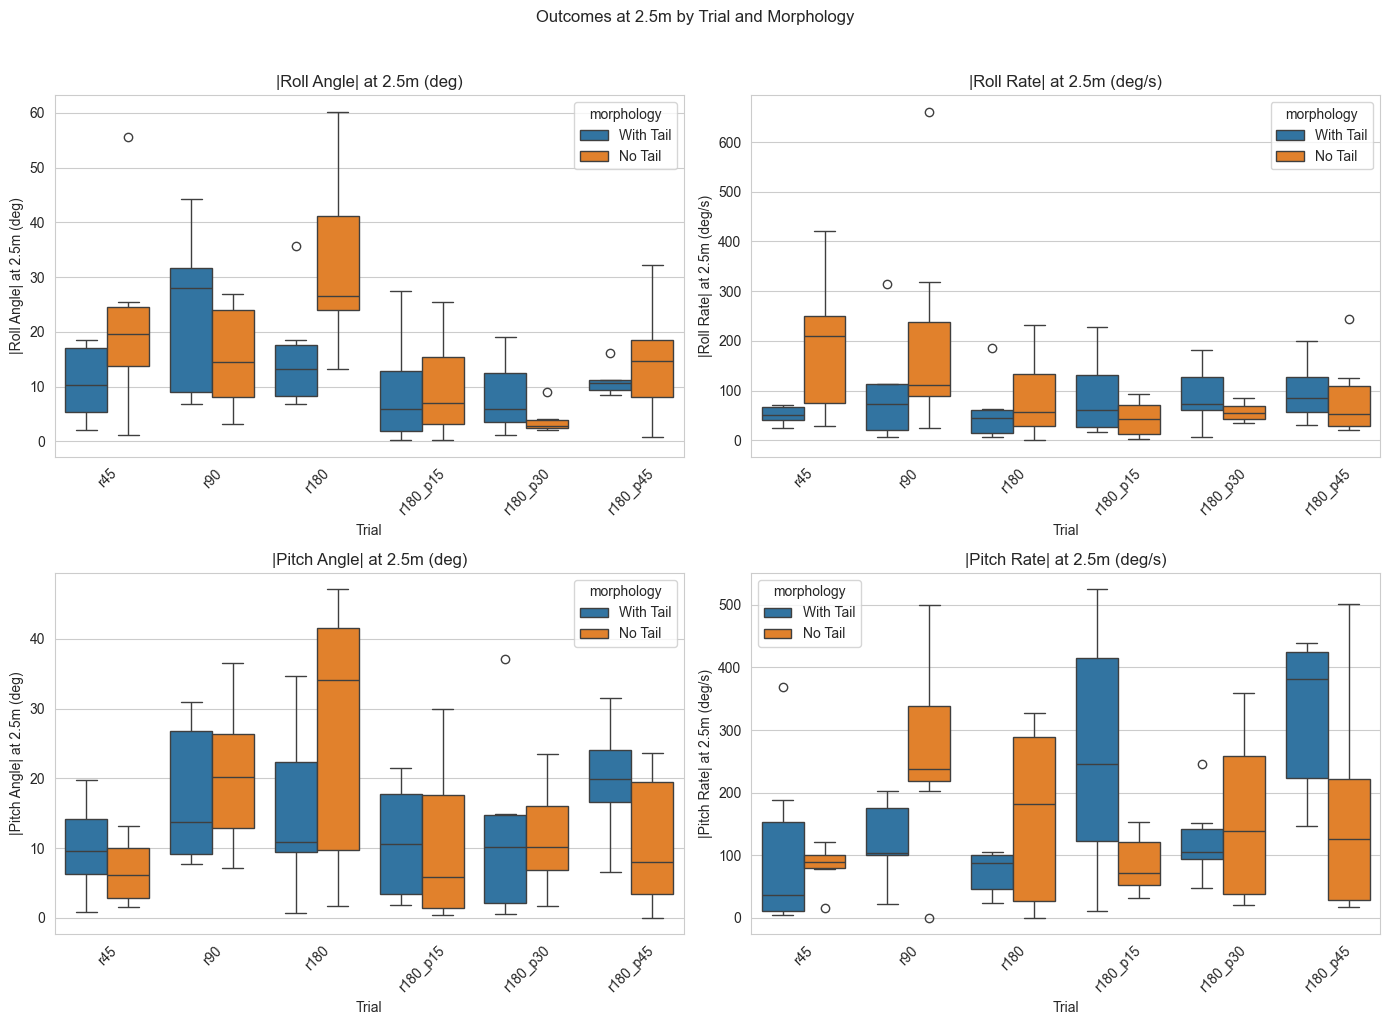

In [8]:
# Visualize outcomes by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx], order=CONDITION_ORDER)
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Outcomes at 2.5m by Trial and Morphology', y=1.02)
plt.tight_layout()
plt.show()


## 4. Main Analysis: Linear Model

**Model:** `|Outcome| ~ Morphology + Trial + Initial_Roll + Initial_Pitch + Initial_RollRate + Initial_PitchRate`

- Controls for trial condition (intentional design) and initial condition noise (drop rig)
- `No Tail` is set as the reference level, so **the coefficient for `C(morphology, Treatment(reference="No Tail"))[T.With Tail]`** reads directly as "how much With Tail differs from No Tail" — positive = tail has *more* deviation (worse), negative = tail has *less* deviation (better)
- Reported alongside the standard (nonrobust) SEs are HC3 heteroscedasticity-robust SEs, since Section 8 finds non-normal, heteroscedastic residuals on 3 of 4 outcomes — if HC3 and nonrobust disagree substantially, trust HC3
- A condition-number warning shows up in some model summaries below (~6,000). This comes from `pitch_initial` being nearly collinear with the trial dummies — the three pitch conditions are *defined* by their initial pitch offset, so there's little within-condition variation left to separate the two. It inflates the *trial* coefficients' standard errors, not the morphology coefficient (which lives in a different, well-conditioned subspace); `stats_final_v2.ipynb` demonstrates this directly by re-fitting with within-trial-centered covariates, which reproduces an identical morphology coefficient at a much lower condition number.

In [9]:
def print_effect(model, label, matched_initial_var=None):
    coef = model.params[MORPH_PARAM]
    pval = model.pvalues[MORPH_PARAM]
    ci   = model.conf_int().loc[MORPH_PARAM]

    model_hc3 = smf.ols(model.model.formula, data=df).fit(cov_type='HC3')
    pval_hc3  = model_hc3.pvalues[MORPH_PARAM]

    print(f"Tail effect on {label}")
    print(f"  Coefficient        : {coef:+.2f} (With Tail vs No Tail)")
    print(f"  95% CI             : [{ci[0]:.2f}, {ci[1]:.2f}]")
    print(f"  p-value (nonrobust): {pval:.4f}")
    print(f"  p-value (HC3)      : {pval_hc3:.4f}")
    print(f"  R²                 : {model.rsquared:.3f}")
    print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'} (nonrobust); {'✅ SIGNIFICANT' if pval_hc3 < 0.05 else '⚠️ NOT SIGNIFICANT'} (HC3)")

    flagged = [v for v in confound_flags if confound_flags[v]]
    if flagged:
        matched_note = f" (matched: {matched_initial_var})" if matched_initial_var in flagged else ""
        print(f"  ⚠️ Confounded initial variable(s) in Diagnostic A: {flagged}{matched_note} — interpret with caution")


### 4.1 |Impact Roll Angle|

In [10]:
formula = f"abs_roll_2p5m ~ {FORMULA_BASE}"
model_roll_angle = smf.ols(formula, data=df).fit()
print(model_roll_angle.summary())


                            OLS Regression Results                            
Dep. Variable:          abs_roll_2p5m   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     2.219
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0282
Time:                        16:19:18   Log-Likelihood:                -273.89
No. Observations:                  72   AIC:                             569.8
Df Residuals:                      61   BIC:                             594.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [11]:
print_effect(model_roll_angle, '|Impact Roll Angle|', matched_initial_var='roll_initial')

Tail effect on |Impact Roll Angle|
  Coefficient        : -4.13 (With Tail vs No Tail)
  95% CI             : [-9.84, 1.58]
  p-value (nonrobust): 0.1536
  p-value (HC3)      : 0.2006
  R²                 : 0.267
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.2 |Impact Roll Rate|

In [12]:
formula = f"abs_rollrate_2p5m ~ {FORMULA_BASE}"
model_roll_rate = smf.ols(formula, data=df).fit()
print(model_roll_rate.summary())


                            OLS Regression Results                            
Dep. Variable:      abs_rollrate_2p5m   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     1.668
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.109
Time:                        16:19:18   Log-Likelihood:                -430.47
No. Observations:                  72   AIC:                             882.9
Df Residuals:                      61   BIC:                             908.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [13]:
print_effect(model_roll_rate, '|Impact Roll Rate|', matched_initial_var='rollrate_initial')

Tail effect on |Impact Roll Rate|
  Coefficient        : -37.31 (With Tail vs No Tail)
  95% CI             : [-87.57, 12.95]
  p-value (nonrobust): 0.1429
  p-value (HC3)      : 0.1780
  R²                 : 0.215
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.3 |Impact Pitch Angle|

In [14]:
formula = f"abs_pitch_2p5m ~ {FORMULA_BASE}"
model_pitch_angle = smf.ols(formula, data=df).fit()
print(model_pitch_angle.summary())


                            OLS Regression Results                            
Dep. Variable:         abs_pitch_2p5m   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     2.421
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0169
Time:                        16:19:18   Log-Likelihood:                -266.75
No. Observations:                  72   AIC:                             555.5
Df Residuals:                      61   BIC:                             580.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [15]:
print_effect(model_pitch_angle, '|Impact Pitch Angle|', matched_initial_var='pitch_initial')

Tail effect on |Impact Pitch Angle|
  Coefficient        : +0.76 (With Tail vs No Tail)
  95% CI             : [-4.41, 5.94]
  p-value (nonrobust): 0.7693
  p-value (HC3)      : 0.7867
  R²                 : 0.284
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.4 |Impact Pitch Rate|

In [16]:
formula = f"abs_pitchrate_2p5m ~ {FORMULA_BASE}"
model_pitch_rate = smf.ols(formula, data=df).fit()
print(model_pitch_rate.summary())


                            OLS Regression Results                            
Dep. Variable:     abs_pitchrate_2p5m   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.147
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.344
Time:                        16:19:18   Log-Likelihood:                -452.74
No. Observations:                  72   AIC:                             927.5
Df Residuals:                      61   BIC:                             952.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [17]:
print_effect(model_pitch_rate, '|Impact Pitch Rate|', matched_initial_var='pitchrate_initial')

Tail effect on |Impact Pitch Rate|
  Coefficient        : +18.70 (With Tail vs No Tail)
  95% CI             : [-49.78, 87.18]
  p-value (nonrobust): 0.5870
  p-value (HC3)      : 0.6098
  R²                 : 0.158
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


## 5. Summary of All Results

In [18]:
models = [
    (model_roll_angle,  '|Roll Angle| (deg)',   'roll_initial'),
    (model_roll_rate,   '|Roll Rate| (deg/s)',  'rollrate_initial'),
    (model_pitch_angle, '|Pitch Angle| (deg)',  'pitch_initial'),
    (model_pitch_rate,  '|Pitch Rate| (deg/s)', 'pitchrate_initial'),
]

results_summary = []
for model, outcome, matched_var in models:
    coef = model.params[MORPH_PARAM]
    pval = model.pvalues[MORPH_PARAM]
    ci   = model.conf_int().loc[MORPH_PARAM]

    # HC3 is the SE we said to trust in Section 4 (non-normal residuals) — the CI and significance
    # flag we lead with below should come from the same fit, not the nonrobust one.
    model_hc3 = smf.ols(model.model.formula, data=df).fit(cov_type='HC3')
    ci_hc3    = model_hc3.conf_int().loc[MORPH_PARAM]
    pval_hc3  = model_hc3.pvalues[MORPH_PARAM]

    sig  = '✅' if pval_hc3 < 0.05 else '⚠️'
    flagged = [v for v in confound_flags if confound_flags[v]]
    note = f'(caution: {", ".join(flagged)} confounded)' if flagged else ''
    results_summary.append({
        'Outcome': outcome,
        'Coef': f"{coef:+.2f}",
        '95% CI (nonrobust)': f"[{ci[0]:.2f}, {ci[1]:.2f}]",
        '95% CI (HC3)': f"[{ci_hc3[0]:.2f}, {ci_hc3[1]:.2f}]",
        'p-value (nonrobust)': f"{pval:.4f}",
        'p-value (HC3)': f"{pval_hc3:.4f}",
        'Sig': sig,
        'R²': f"{model.rsquared:.3f}",
        'Note': note
    })

print("="*110)
print("SUMMARY: Tail Effects (With Tail vs No Tail)")
print("Controlling for: Trial condition + Initial conditions | Front IMU only | Absolute values")
print("="*110)
print(pd.DataFrame(results_summary).to_string(index=False))
print("\nNegative coefficient = With Tail has lower absolute deviation than No Tail (tail helps)")
print("Positive coefficient = With Tail has higher absolute deviation than No Tail (tail hurts)")

roll_angle_row = results_summary[0]  # |Roll Angle| (deg)
print(f"\nRead the HC3 CIs, not just the p-values — that's the SE we're trusting given the non-normal")
print(f"residuals. E.g. roll angle's HC3 CI is {roll_angle_row['95% CI (HC3)']} (nonrobust was")
print(f"{roll_angle_row['95% CI (nonrobust)']}): consistent with a tail benefit inside that range,")
print(f"and rules out a tail HARM larger than the CI's upper bound.")


SUMMARY: Tail Effects (With Tail vs No Tail)
Controlling for: Trial condition + Initial conditions | Front IMU only | Absolute values
             Outcome   Coef 95% CI (nonrobust)    95% CI (HC3) p-value (nonrobust) p-value (HC3) Sig    R² Note
  |Roll Angle| (deg)  -4.13      [-9.84, 1.58]  [-10.45, 2.19]              0.1536        0.2006  ⚠️ 0.267     
 |Roll Rate| (deg/s) -37.31    [-87.57, 12.95] [-91.61, 16.98]              0.1429        0.1780  ⚠️ 0.215     
 |Pitch Angle| (deg)  +0.76      [-4.41, 5.94]   [-4.76, 6.28]              0.7693        0.7867  ⚠️ 0.284     
|Pitch Rate| (deg/s) +18.70    [-49.78, 87.18] [-53.11, 90.51]              0.5870        0.6098  ⚠️ 0.158     

Negative coefficient = With Tail has lower absolute deviation than No Tail (tail helps)
Positive coefficient = With Tail has higher absolute deviation than No Tail (tail hurts)

Read the HC3 CIs, not just the p-values — that's the SE we're trusting given the non-normal
residuals. E.g. roll angle's HC3 CI

## 6. Per-Trial Analysis

The overall analysis pools trials and may wash out effects that only show up in specific conditions — but running 6 conditions × 2 tests (t-test + MWU) × 4 outcomes is 48 comparisons, and at N≈5–7 per group per trial each individual test is very low powered. Two complementary ways to handle this:

1. **Formal interaction test**: does the tail's effect actually differ across trial conditions? A `morphology × trial` interaction term in the main model tests this directly, with much better power than 6 separate n≈6 comparisons.
2. **Per-trial t-tests, Bonferroni-corrected**: for exploratory/descriptive purposes, shown below with `α_adjusted = 0.05 / 12` (matching `stats_final.py`) rather than raw p-values — the version that gets plotted with significance markers.

> ⚠️ **Low power either way:** N≈5–7 per group per trial. Non-significance ≠ no effect.

In [19]:
# Formal test: does the tail effect vary by trial condition?
# Bonferroni-corrected across the 4 outcomes, since we're running this test 4 times.
print("Interaction test: morphology × trial (Bonferroni-corrected across 4 outcomes)")
print("=" * 80)

interaction_ps = {}
for var, label in outcomes:
    formula_int = f"{var} ~ {MORPH_TERM} * C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
    m_int = smf.ols(formula_int, data=df).fit()
    anova_int = anova_lm(m_int, typ=2)
    int_rows = [r for r in anova_int.index if ':' in r]
    p_int = anova_int.loc[int_rows[0], 'PR(>F)'] if int_rows else np.nan
    p_int_adj = min(p_int * len(outcomes), 1.0)
    interaction_ps[label] = (p_int, p_int_adj)
    sig_raw = '✅ (raw)' if p_int < 0.05 else ''
    sig_adj = '✅ (Bonferroni)' if p_int_adj < 0.05 else ''
    print(f"  {label:30s}: raw p = {p_int:.4f} {sig_raw:15s} adjusted p = {p_int_adj:.4f} {sig_adj}")
    print(f"    (model fits {len(m_int.params)} params on {int(m_int.df_resid)} residual df, n={int(m_int.nobs)})")

any_raw_sig = any(p < 0.05 for p, _ in interaction_ps.values())
any_adj_sig = any(p_adj < 0.05 for _, p_adj in interaction_ps.values())

print()
if any_raw_sig and not any_adj_sig:
    flagged = [l for l, (p, _) in interaction_ps.items() if p < 0.05]
    print(f"⚠️→✅ {flagged} crossed the raw p<0.05 threshold but NOT the Bonferroni-adjusted one.")
    print("  With 4 tests run, one crossing raw 0.05 by chance is close to the expected false-positive")
    print("  rate — treat it as noise rather than a real trial-specific tail effect, especially given")
    print("  the interaction model's parameter count relative to residual df (see counts above).")
elif any_adj_sig:
    print("⚠️ At least one interaction survives Bonferroni correction — the tail effect genuinely")
    print("  differs by trial condition here. Pooling into a single overall coefficient (Section 5)")
    print("  would misrepresent that outcome; report it per-trial instead.")
else:
    print("✅ No interaction reaches even the raw 0.05 threshold — pooling trials into the overall")
    print("  Section 5 coefficient is well supported as the better-powered summary.")


Interaction test: morphology × trial (Bonferroni-corrected across 4 outcomes)
  |Roll Angle| at 2.5m (deg)    : raw p = 0.1099                 adjusted p = 0.4396 
    (model fits 16 params on 56 residual df, n=72)
  |Roll Rate| at 2.5m (deg/s)   : raw p = 0.4283                 adjusted p = 1.0000 
    (model fits 16 params on 56 residual df, n=72)
  |Pitch Angle| at 2.5m (deg)   : raw p = 0.2177                 adjusted p = 0.8709 
    (model fits 16 params on 56 residual df, n=72)
  |Pitch Rate| at 2.5m (deg/s)  : raw p = 0.0157 ✅ (raw)         adjusted p = 0.0627 
    (model fits 16 params on 56 residual df, n=72)

⚠️→✅ ['|Pitch Rate| at 2.5m (deg/s)'] crossed the raw p<0.05 threshold but NOT the Bonferroni-adjusted one.
  With 4 tests run, one crossing raw 0.05 by chance is close to the expected false-positive
  rate — treat it as noise rather than a real trial-specific tail effect, especially given
  the interaction model's parameter count relative to residual df (see counts abov

In [20]:
ALPHA_CORRECTED = 0.05 / N_COMPARISONS

per_trial_results = []
for trial in CONDITION_ORDER:
    dft = df[df['trial'] == trial]
    row = {'Trial': trial}
    for var, label in outcomes:
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        diff = a.mean() - b.mean()  # With Tail minus No Tail
        _, p_t = stats.ttest_ind(a, b)
        _, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
        p_t_adj = min(p_t * N_COMPARISONS, 1.0)
        row[f'{label} diff']       = round(diff, 1)
        row[f'{label} t p_adj']    = f"{p_t_adj:.3f}{'  ✅' if p_t_adj < 0.05 else ''}"
        row[f'{label} MWU p_raw']  = f"{p_u:.3f}"
    per_trial_results.append(row)

per_trial_df = pd.DataFrame(per_trial_results).set_index('Trial')

print('=' * 110)
print('PER-TRIAL TAIL EFFECTS (With Tail vs No Tail)')
print(f'Bonferroni-corrected t-test (alpha_adj={ALPHA_CORRECTED:.4f}) + raw Mann-Whitney U | N≈5-7/group/trial')
print('=' * 110)
print(per_trial_df.to_string())
print('\n✅ = p_adj < 0.05 | Positive diff = With Tail has more deviation')


PER-TRIAL TAIL EFFECTS (With Tail vs No Tail)
Bonferroni-corrected t-test (alpha_adj=0.0021) + raw Mann-Whitney U | N≈5-7/group/trial
          |Roll Angle| at 2.5m (deg) diff |Roll Angle| at 2.5m (deg) t p_adj |Roll Angle| at 2.5m (deg) MWU p_raw  |Roll Rate| at 2.5m (deg/s) diff |Roll Rate| at 2.5m (deg/s) t p_adj |Roll Rate| at 2.5m (deg/s) MWU p_raw  |Pitch Angle| at 2.5m (deg) diff |Pitch Angle| at 2.5m (deg) t p_adj |Pitch Angle| at 2.5m (deg) MWU p_raw  |Pitch Rate| at 2.5m (deg/s) diff |Pitch Rate| at 2.5m (deg/s) t p_adj |Pitch Rate| at 2.5m (deg/s) MWU p_raw
Trial                                                                                                                                                                                                                                                                                                                                                                                                                                    

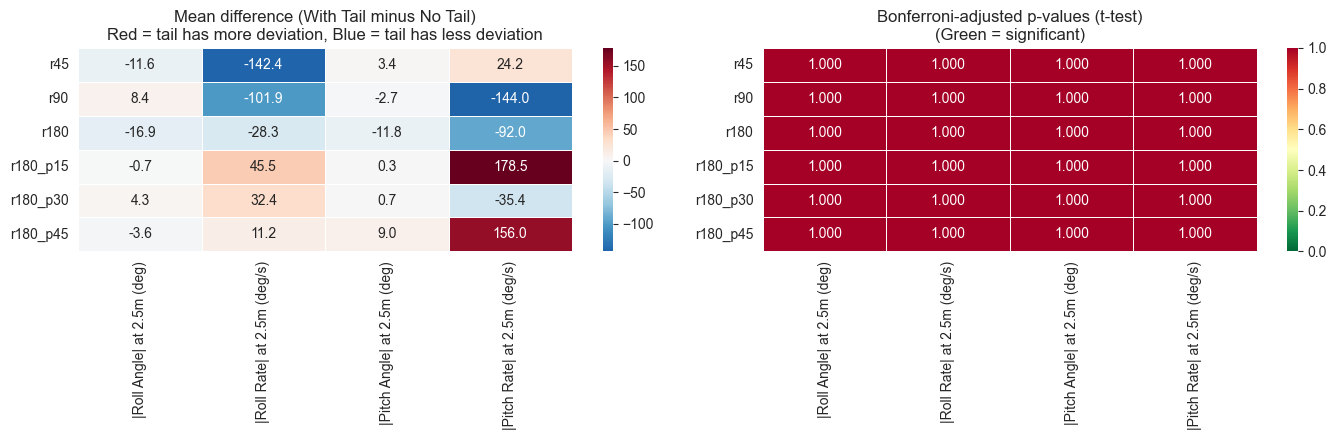

In [21]:
# Heatmaps: mean difference and Bonferroni-adjusted p-values
diff_data, pval_data = [], []
for trial in CONDITION_ORDER:
    dft = df[df['trial'] == trial]
    diff_row, pval_row = [], []
    for var, _ in outcomes:
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        diff_row.append(a.mean() - b.mean())
        _, p = stats.ttest_ind(a, b)
        pval_row.append(min(p * N_COMPARISONS, 1.0))
    diff_data.append(diff_row); pval_data.append(pval_row)

col_labels = [l for _, l in outcomes]
diff_df = pd.DataFrame(diff_data, index=CONDITION_ORDER, columns=col_labels)
pval_df = pd.DataFrame(pval_data, index=CONDITION_ORDER, columns=col_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(diff_df, annot=True, fmt='.1f', center=0, cmap='RdBu_r', ax=axes[0], linewidths=0.5)
axes[0].set_title('Mean difference (With Tail minus No Tail)\nRed = tail has more deviation, Blue = tail has less deviation')
sns.heatmap(pval_df, annot=True, fmt='.3f', vmin=0, vmax=1.0, cmap='RdYlGn_r', ax=axes[1], linewidths=0.5)
axes[1].set_title('Bonferroni-adjusted p-values (t-test)\n(Green = significant)')
plt.tight_layout()
plt.show()


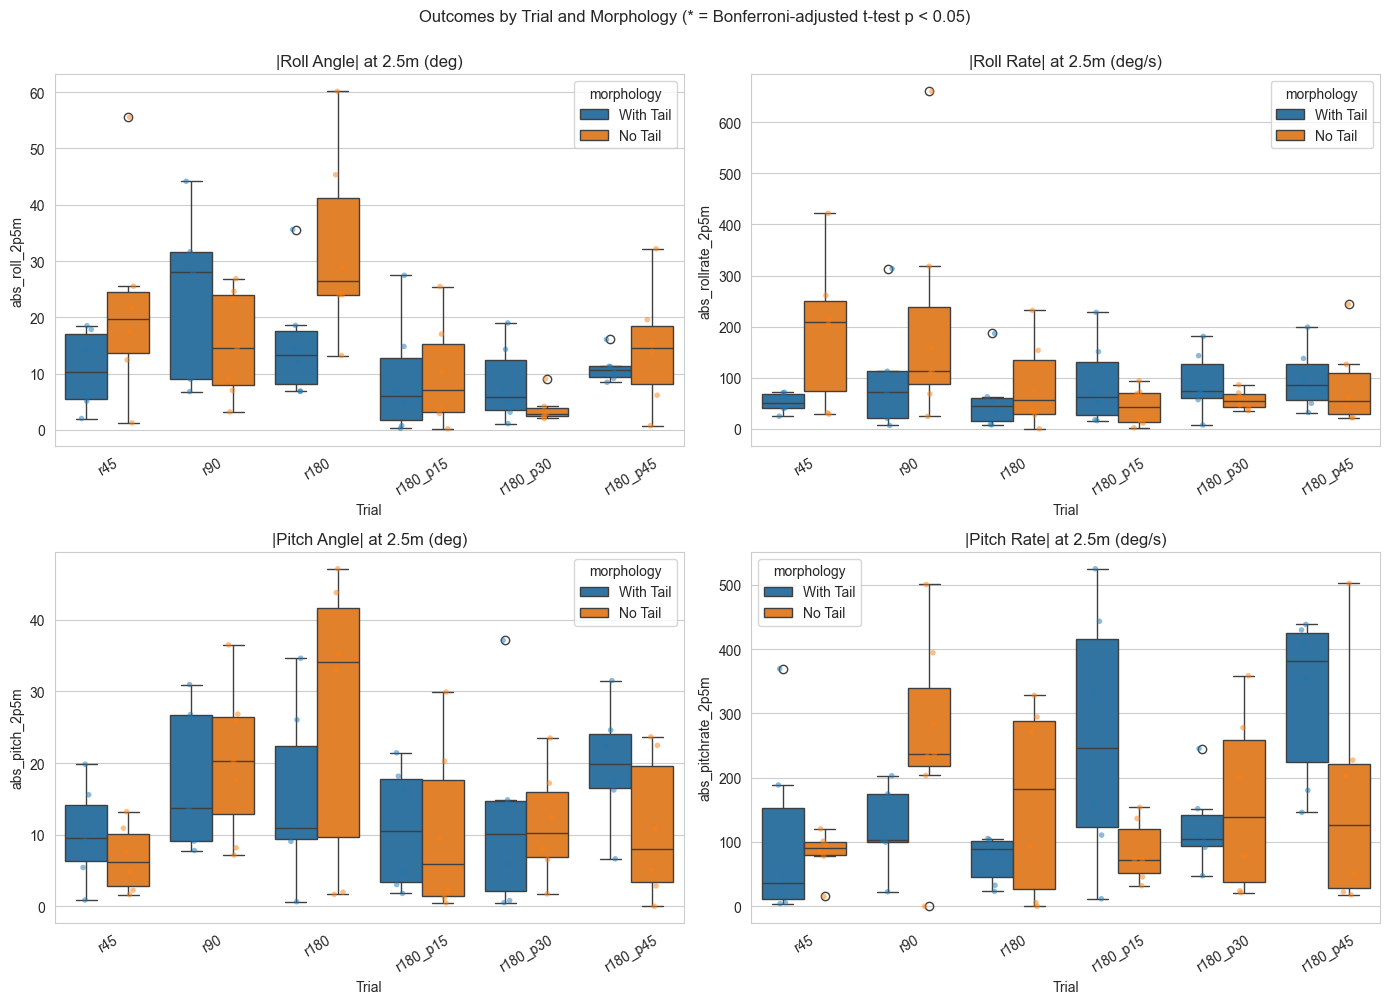

In [22]:
# Box plots per trial per outcome, with Bonferroni-corrected significance markers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    ax = axes[idx]
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=ax, order=CONDITION_ORDER)
    sns.stripplot(data=df, x='trial', y=var, hue='morphology', ax=ax,
                  dodge=True, alpha=0.5, size=4, order=CONDITION_ORDER, legend=False)

    ymax = df[var].max()
    for tidx, trial in enumerate(CONDITION_ORDER):
        dft = df[df['trial'] == trial]
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        _, p = stats.ttest_ind(a, b)
        p_adj = min(p * N_COMPARISONS, 1.0)
        if p_adj < 0.05:
            ax.text(tidx, ymax * 1.05, '*', ha='center', fontsize=20, color='red', fontweight='bold')

    ax.set_title(label)
    ax.set_xlabel('Trial')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Outcomes by Trial and Morphology (* = Bonferroni-adjusted t-test p < 0.05)', y=1.00)
plt.tight_layout()
plt.show()


## 7. Effect Size Visualization

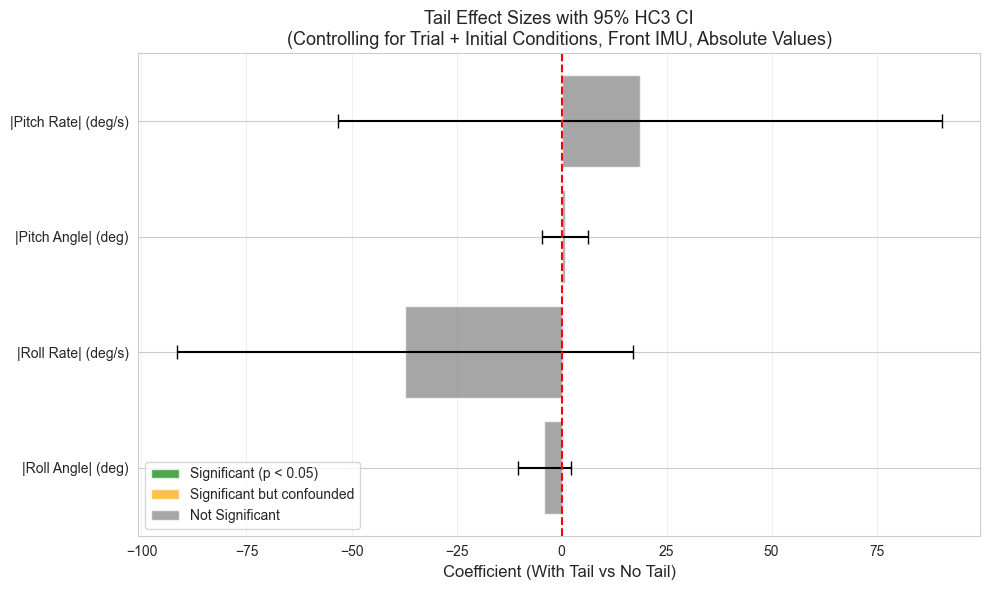

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

outcomes_list = [r['Outcome'] for r in results_summary]
coeffs    = [float(r['Coef']) for r in results_summary]
ci_lower  = [float(r['95% CI (HC3)'].split(',')[0].strip('[')) for r in results_summary]
ci_upper  = [float(r['95% CI (HC3)'].split(',')[1].strip(']')) for r in results_summary]
pvals     = [float(r['p-value (HC3)']) for r in results_summary]
confounds = [r['Note'] != '' for r in results_summary]

colors = []
for sig, conf in zip([p < 0.05 for p in pvals], confounds):
    if sig and not conf:
        colors.append('green')
    elif sig and conf:
        colors.append('orange')
    else:
        colors.append('gray')

y_pos = np.arange(len(outcomes_list))
xerr  = [np.array(coeffs) - np.array(ci_lower), np.array(ci_upper) - np.array(coeffs)]

ax.barh(y_pos, coeffs, xerr=xerr, color=colors, alpha=0.7, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes_list)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Coefficient (With Tail vs No Tail)', fontsize=12)
ax.set_title('Tail Effect Sizes with 95% HC3 CI\n(Controlling for Trial + Initial Conditions, Front IMU, Absolute Values)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green',  alpha=0.7, label='Significant (p < 0.05)'),
    Patch(facecolor='orange', alpha=0.7, label='Significant but confounded'),
    Patch(facecolor='gray',   alpha=0.7, label='Not Significant')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


## 8. Assumption Checks

In [24]:
print("Normality of Residuals (Shapiro-Wilk):")
print("="*60)
for model, outcome, _ in models:
    stat, p = stats.shapiro(model.resid)
    result = "✅ Normal" if p >= 0.05 else "⚠️ Non-normal"
    print(f"{outcome:25s}: W={stat:.4f}, p={p:.4f} → {result}")

print("\nNon-normal residuals are why Section 4 reports HC3 robust SEs alongside nonrobust ones.")
print("Shapiro-Wilk is also underpowered at this N — check the residual plots below too.")


Normality of Residuals (Shapiro-Wilk):
|Roll Angle| (deg)       : W=0.9206, p=0.0002 → ⚠️ Non-normal
|Roll Rate| (deg/s)      : W=0.8821, p=0.0000 → ⚠️ Non-normal
|Pitch Angle| (deg)      : W=0.9777, p=0.2284 → ✅ Normal
|Pitch Rate| (deg/s)     : W=0.9442, p=0.0031 → ⚠️ Non-normal

Non-normal residuals are why Section 4 reports HC3 robust SEs alongside nonrobust ones.
Shapiro-Wilk is also underpowered at this N — check the residual plots below too.


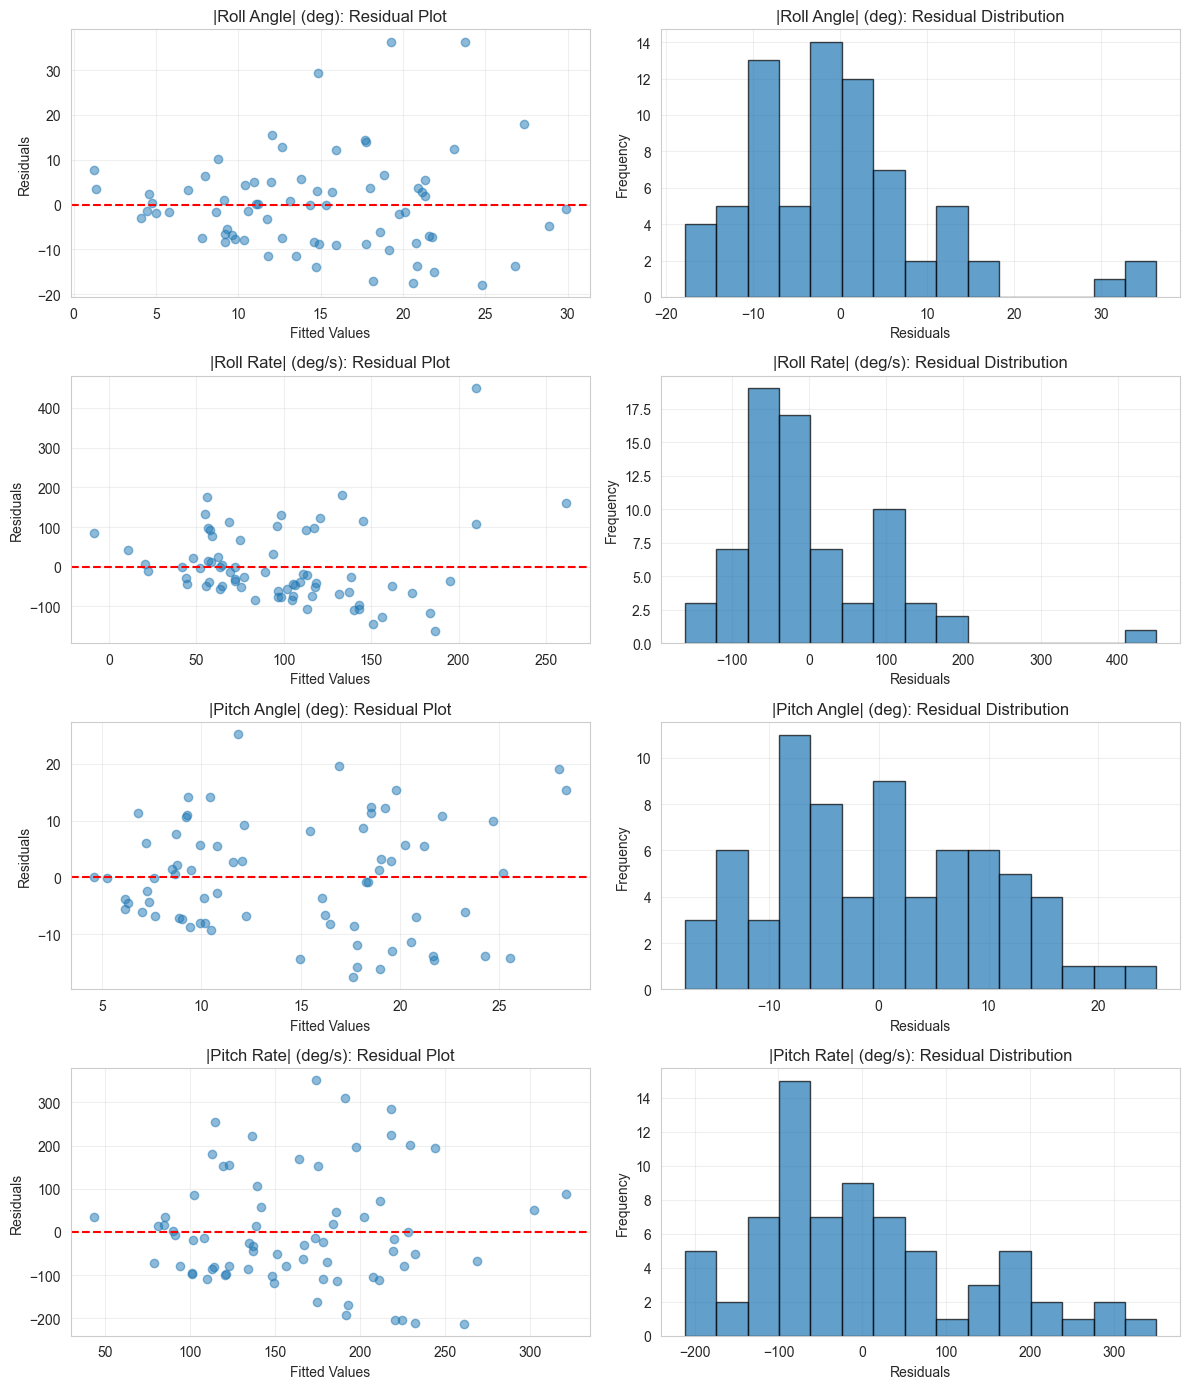

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for idx, (model, outcome, _) in enumerate(models):
    axes[idx, 0].scatter(model.fittedvalues, model.resid, alpha=0.5)
    axes[idx, 0].axhline(0, color='red', linestyle='--')
    axes[idx, 0].set_xlabel('Fitted Values')
    axes[idx, 0].set_ylabel('Residuals')
    axes[idx, 0].set_title(f'{outcome}: Residual Plot')
    axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].hist(model.resid, bins=15, edgecolor='black', alpha=0.7)
    axes[idx, 1].set_xlabel('Residuals')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{outcome}: Residual Distribution')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Interpretation Guide

### How to Read Results:

| Color | Meaning |
|-------|--------|
| 🟢 Green | Significant and clean |
| 🟠 Orange | Significant but a Diagnostic-A initial variable was flagged confounded — interpret with caution |
| ⚫ Gray | Not significant |

**Coefficient interpretation:**
- Negative → With Tail has **less** deviation than No Tail (tail helps)
- Positive → With Tail has **more** deviation than No Tail (tail hurts)
- Primary interest: roll outcomes (the tail actuator primarily affects roll). Pitch outcomes are secondary.

**Overall vs per-trial vs interaction:**
- Overall model (Section 4/5) pools all 6 trial conditions → most power, the headline number
- Interaction test (Section 6) asks whether that pooling is defensible in the first place
- Per-trial tests (Section 6) are exploratory/descriptive only, Bonferroni-corrected — treat as a diagnostic for *where* an effect might concentrate, not a standalone claim

**On "no significant effect":** prefer stating the CI directly (e.g. "consistent with a tail benefit up to ~10°, rules out tail harm beyond ~1.6°") over "not significant," which collapses a range of plausible effects into a binary.

---

### Statistical Notes:
1. **Angle wrapping**: `np.unwrap()` in the processing pipeline can produce values like 355° or -377°. This notebook wraps to [-180, 180] first, *then* takes abs — shortest angular distance from upright.
2. **No cluster-robust SE**: only 6 trial clusters — below the ~30 needed for cluster SE to be reliable. HC3 heteroscedasticity-robust SEs are reported instead (Section 4).
3. **Per-trial tests use no covariates**: with N≈5–7 per group, adding 4 covariates would overfit.
4. **Achieved-power-at-observed-effect (old Section 10) is a monotone function of the p-value** and shouldn't be read as independent evidence — see Section 10 below for the reframed version.

### Known Limitations:
1. Confound status for each initial variable is determined *live* by Diagnostic A above — `confound_flags` propagates into every outcome section, not just the nominally matched one, since roll/pitch are mechanically coupled.
2. Morphology is not randomly interleaved across collection dates — see Diagnostic B. The sensitivity check is reassuring but coarse (date is collinear with trial).
3. Low power per trial (N≈5–7 per group) — non-significance ≠ no effect (Section 10).
4. `r90` has an asymmetric N across morphologies (one With-Tail drop was filtered for falling short of the 2.5 m/0.7 s threshold).

## 10. Power and Precision

Since no significant tail effect was found in the overall model, this section asks two different questions that are easy to conflate:

1. **Design-based MDE**: given this sample size, what effect size *could* this design have reliably caught at 80% power? This doesn't depend on what we observed — it's a property of N alone, and it's the legitimate way to talk about "was this study powered enough."
2. **Achieved power at the observed effect**: shown for reference only. This number is mathematically a monotone transform of the p-value you already have — it cannot tell you anything the p-value didn't, and post-hoc power is a well-known statistical anti-pattern (see Hoenig & Heisey, 2001, *The Abuse of Power*). Don't cite it as independent support for "underpowered"; the MDE comparison already makes that case honestly.

In [26]:
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()
alpha = 0.05
power = 0.80

n_overall   = min((df['morphology'] == 'With Tail').sum(), (df['morphology'] == 'No Tail').sum())
n_per_trial = 6   # typical per-group N per trial (varies 5-7, see Section 1 crosstab)

mde_overall   = power_analysis.solve_power(nobs1=n_overall,   alpha=alpha, power=power)
mde_per_trial = power_analysis.solve_power(nobs1=n_per_trial, alpha=alpha, power=power)

print("Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05 — design-based, not post-hoc")
print("=" * 70)
print(f"  Overall analysis   (N={n_overall} per group): d = {mde_overall:.3f}")
print(f"  Per-trial analysis (N≈{n_per_trial} per group): d = {mde_per_trial:.3f}")
print(f"Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8")


Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05 — design-based, not post-hoc
  Overall analysis   (N=35 per group): d = 0.679
  Per-trial analysis (N≈6 per group): d = 1.796
Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8


In [27]:
# Effect size computed from the ADJUSTED model (coef / sqrt(MSE)), consistent with the model's own
# p-value — not from raw pooled group stats, which would answer a slightly different question.
print("Model-implied effect size (coefficient / sqrt(residual MSE)) — for reference only, see caveat above")
print("=" * 80)

observed_ds_signed = {}
for model, label, _ in models:
    d = model.params[MORPH_PARAM] / np.sqrt(model.mse_resid)
    observed_ds_signed[label] = d
    achieved_power = power_analysis.solve_power(effect_size=abs(d), nobs1=n_overall, alpha=alpha)
    print(f"  {label:25s}: d = {d:+.3f}, achieved power = {achieved_power:.3f}  (informational — see caveat above)")

print(f"\nMDE (overall, 80% power): d = {mde_overall:.3f}")
print("This says the design could reliably catch effects at or above this size; observed effects")
print("below it don't confirm 'no effect', just that this N can't resolve effects that small.")


Model-implied effect size (coefficient / sqrt(residual MSE)) — for reference only, see caveat above
  |Roll Angle| (deg)       : d = -0.350, achieved power = 0.303  (informational — see caveat above)
  |Roll Rate| (deg/s)      : d = -0.359, achieved power = 0.317  (informational — see caveat above)
  |Pitch Angle| (deg)      : d = +0.071, achieved power = 0.060  (informational — see caveat above)
  |Pitch Rate| (deg/s)     : d = +0.132, achieved power = 0.085  (informational — see caveat above)

MDE (overall, 80% power): d = 0.679
This says the design could reliably catch effects at or above this size; observed effects
below it don't confirm 'no effect', just that this N can't resolve effects that small.


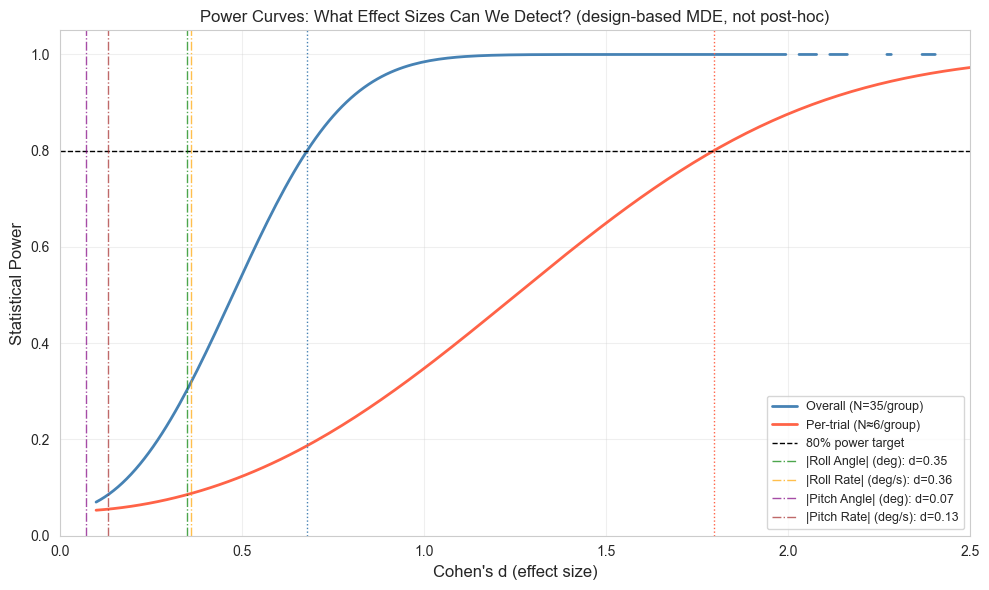

Summary:
  Overall analysis is powered for d >= 0.68
  Per-trial analysis is powered for d >= 1.80 (very large effect)
  Model-implied effect sizes range from d = 0.07 to 0.36


In [28]:
# ── Power curve plot ─────────────────────────────────────────────────────────
effect_sizes = np.linspace(0.1, 2.5, 200)

power_overall   = [power_analysis.solve_power(effect_size=d, nobs1=n_overall,   alpha=alpha) for d in effect_sizes]
power_per_trial = [power_analysis.solve_power(effect_size=d, nobs1=n_per_trial, alpha=alpha) for d in effect_sizes]

observed_ds = {label: abs(d) for label, d in observed_ds_signed.items()}

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(effect_sizes, power_overall,   label=f'Overall (N={n_overall}/group)',   color='steelblue', linewidth=2)
ax.plot(effect_sizes, power_per_trial, label=f'Per-trial (N≈{n_per_trial}/group)', color='tomato',    linewidth=2)
ax.axhline(0.80, color='black', linestyle='--', linewidth=1, label='80% power target')
ax.axvline(mde_overall,   color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mde_per_trial, color='tomato',    linestyle=':', linewidth=1)

colors = ['green', 'orange', 'purple', 'brown']
for (label, d), col in zip(observed_ds.items(), colors):
    ax.axvline(d, color=col, linestyle='-.', linewidth=1, alpha=0.7, label=f'{label}: d={d:.2f}')

ax.set_xlabel("Cohen's d (effect size)", fontsize=12)
ax.set_ylabel("Statistical Power", fontsize=12)
ax.set_title("Power Curves: What Effect Sizes Can We Detect? (design-based MDE, not post-hoc)", fontsize=12)
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Overall analysis is powered for d >= {mde_overall:.2f}")
print(f"  Per-trial analysis is powered for d >= {mde_per_trial:.2f} (very large effect)")
print(f"  Model-implied effect sizes range from d = {min(observed_ds.values()):.2f} to {max(observed_ds.values()):.2f}")


---

## Sections 11–16: Exploratory Robustness Checks

Everything from here on was designed *after* examining the Sections 1–10 results, in response to specific questions about them (assumption violations, an unaudited outcome definition, an unaudited exclusion rule). Treat these as hypothesis-generating stress tests of the primary analysis, not as a second confirmatory analysis — they weren't planned before the data were seen.

---

## 11. Permutation Test on the Tail Coefficient

The parametric p-values in Section 4 assume the OLS error structure is (at least approximately) correct. Section 8 shows that's shaky for 3 of 4 outcomes. A permutation test sidesteps the distributional assumption entirely: shuffle the `morphology` labels *within each trial* (preserving the trial-level design and each trial's With/No-Tail group sizes), refit the identical model, and see how often a random relabeling produces a coefficient at least as extreme as the one actually observed.

If the permutation p-value and the parametric p-value agree, the parametric result wasn't an artifact of the normality assumption. If they disagree substantially, trust the permutation version.

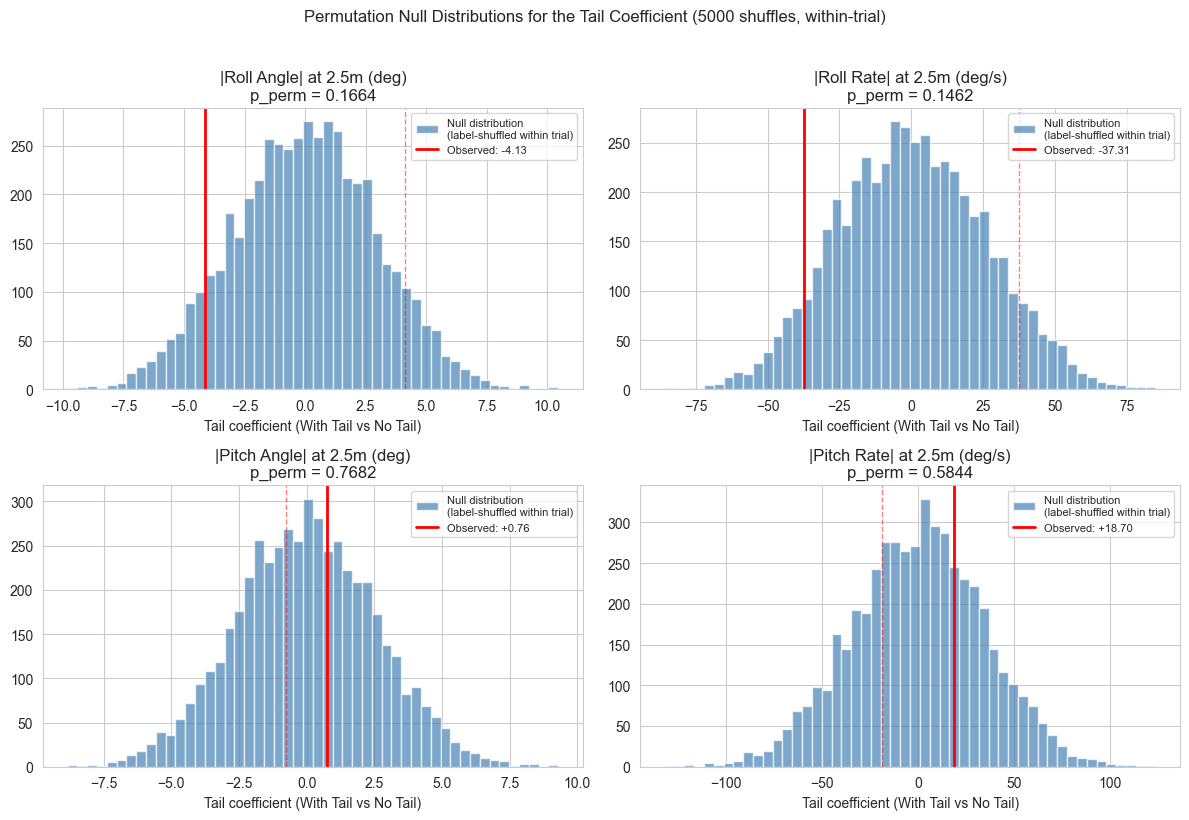

Parametric vs permutation p-values
  |Roll Angle| at 2.5m (deg): parametric p = 0.1536   permutation p = 0.1664
  |Roll Rate| at 2.5m (deg/s): parametric p = 0.1429   permutation p = 0.1462
  |Pitch Angle| at 2.5m (deg): parametric p = 0.7693   permutation p = 0.7682
  |Pitch Rate| at 2.5m (deg/s): parametric p = 0.5870   permutation p = 0.5844


In [29]:
def permutation_test_morphology(var, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    formula = f"{var} ~ {FORMULA_BASE}"
    observed = smf.ols(formula, data=df).fit().params[MORPH_PARAM]

    df_perm = df.copy()
    null_coefs = np.empty(n_perm)
    for i in range(n_perm):
        df_perm['morphology'] = df.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values))
        null_coefs[i] = smf.ols(formula, data=df_perm).fit().params[MORPH_PARAM]

    p_perm = np.mean(np.abs(null_coefs) >= np.abs(observed))
    return observed, null_coefs, p_perm

perm_results = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    observed, null_coefs, p_perm = permutation_test_morphology(var)
    perm_results[label] = (observed, p_perm)

    ax = axes[idx]
    ax.hist(null_coefs, bins=50, color='steelblue', alpha=0.7, label='Null distribution\n(label-shuffled within trial)')
    ax.axvline(observed, color='red', linewidth=2, label=f'Observed: {observed:+.2f}')
    ax.axvline(-observed, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{label}\np_perm = {p_perm:.4f}')
    ax.set_xlabel('Tail coefficient (With Tail vs No Tail)')
    ax.legend(fontsize=8)

plt.suptitle('Permutation Null Distributions for the Tail Coefficient (5000 shuffles, within-trial)', y=1.02)
plt.tight_layout()
plt.show()

var_to_model = {
    'abs_roll_2p5m':      model_roll_angle,
    'abs_rollrate_2p5m':  model_roll_rate,
    'abs_pitch_2p5m':     model_pitch_angle,
    'abs_pitchrate_2p5m': model_pitch_rate,
}

print("Parametric vs permutation p-values")
print("=" * 60)
for var, label in outcomes:
    p_param = var_to_model[var].pvalues[MORPH_PARAM]
    p_perm  = perm_results[label][1]
    print(f"  {label:25s}: parametric p = {p_param:.4f}   permutation p = {p_perm:.4f}")


## 12. Variance / Spread Analysis

Every test so far compares **means**. But a righting mechanism could plausibly make outcomes more *consistent* without moving the average — worth checking directly, especially since the roll outcomes' standard deviations look visually different between groups in Section 3.

**Two methodological points, not one:**

1. The classic F-test for equality of variances assumes normality, and Section 8 already showed these residuals are not normal (roll rate kurtosis ≈ 6–8). The F-test is known to be very sensitive to exactly that violation. So this section runs the naive F-test (shown for comparison, not as evidence) alongside Levene's test centered on the median (Brown-Forsythe — robust to non-normality) and a permutation test on the variance ratio (distribution-free).
2. All three of those need to run on **trial/covariate-adjusted residuals**, not the raw outcome values. The raw values mix two sources of spread: genuine within-condition (release-to-release) consistency, and between-condition difficulty (r45 is just an easier catch than r180_p45). Pooling across conditions inflates the apparent variance difference with condition-mix noise. So each variable below is first residualized against `C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial` — a model that does **not** include morphology — and the variance tests run on those residuals, split by the true morphology label. The permutation test correspondingly shuffles the morphology label within trial, consistent with the mean test's design in Section 11.

In [30]:
from scipy.stats import f as f_dist

RESIDUALIZING_FORMULA = "{var} ~ C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"

def variance_tests(var, label, n_perm=5000, seed=0):
    # Residualize against trial + initial conditions, WITHOUT morphology, so what's left is
    # release-to-release spread net of condition difficulty — not contaminated by which
    # conditions happen to be harder, and not by the morphology mean shift either.
    m_blind = smf.ols(RESIDUALIZING_FORMULA.format(var=var), data=df).fit()
    resid = m_blind.resid.values
    morph = df['morphology'].values
    trial = df['trial'].values

    a = resid[morph == 'With Tail']
    b = resid[morph == 'No Tail']

    # Naive F-test (assumes normality — shown to demonstrate why it's misleading here)
    F = b.var(ddof=1) / a.var(ddof=1)
    dfn, dfd = len(b) - 1, len(a) - 1
    p_naive = 2 * min(f_dist.cdf(F, dfn, dfd), 1 - f_dist.cdf(F, dfn, dfd))

    # Brown-Forsythe (Levene centered on median) — robust to non-normality
    stat_bf, p_bf = stats.levene(a, b, center='median')

    # Permutation test on the variance ratio — shuffle morphology WITHIN trial (same design as
    # Section 11's mean test), recompute the ratio on the same fixed residuals each time.
    rng = np.random.default_rng(seed)
    obs_ratio = F
    null_ratios = np.empty(n_perm)
    df_shuf = pd.DataFrame({'trial': trial, 'morphology': morph})
    for i in range(n_perm):
        perm_morph = df_shuf.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values)).values
        pa, pb = resid[perm_morph == 'With Tail'], resid[perm_morph == 'No Tail']
        null_ratios[i] = pb.var(ddof=1) / pa.var(ddof=1)
    extremity = max(obs_ratio, 1 / obs_ratio)
    p_perm = np.mean((null_ratios >= extremity) | (null_ratios <= 1 / extremity))

    return {
        'label': label, 'var_ratio (No/With, on residuals)': obs_ratio,
        'naive F p': p_naive, 'Brown-Forsythe p': p_bf, 'permutation p': p_perm,
    }

var_results = [variance_tests(var, label) for var, label in outcomes]
var_df = pd.DataFrame(var_results).set_index('label')
print("Variance-ratio tests on trial/covariate-adjusted residuals: does the tail reduce spread?")
print("=" * 100)
print(var_df.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Read the naive-F column skeptically — it's the one most likely to disagree with the two robust")
print("tests, and that disagreement is itself the finding: a naive-F 'significant' variance effect")
print("that Brown-Forsythe/permutation don't confirm means non-normality was driving the naive result,")
print("not a real spread difference.")
for r in var_results:
    naive_sig = r['naive F p'] < 0.05
    robust_sig = r['Brown-Forsythe p'] < 0.05 or r['permutation p'] < 0.05
    if naive_sig and not robust_sig:
        verdict = "naive F flags it, robust tests do NOT confirm — treat as unconfirmed"
    elif robust_sig:
        verdict = "robust test(s) also significant — worth taking seriously"
    else:
        verdict = "no test flags this one"
    print(f"  {r['label']:25s} ratio={r['var_ratio (No/With, on residuals)']:.2f}: {verdict}")
print()
print("Any variance-reduction story here is, at most, a hypothesis for a better-powered follow-up —")
print("not a confirmed result — and residualizing against trial/covariates (vs. raw pooled values)")
print("shrinks the apparent effect further, which is itself informative about how much of the raw")
print("difference was condition-mix noise rather than true within-condition consistency.")


Variance-ratio tests on trial/covariate-adjusted residuals: does the tail reduce spread?
                              var_ratio (No/With, on residuals)  naive F p  Brown-Forsythe p  permutation p
label                                                                                                      
|Roll Angle| at 2.5m (deg)                               1.6601     0.1406            0.3579         0.3686
|Roll Rate| at 2.5m (deg/s)                              2.1993     0.0230            0.3290         0.2646
|Pitch Angle| at 2.5m (deg)                              1.0947     0.7930            0.8944         0.7510
|Pitch Rate| at 2.5m (deg/s)                             1.1568     0.6717            0.4430         0.6782

Read the naive-F column skeptically — it's the one most likely to disagree with the two robust
tests, and that disagreement is itself the finding: a naive-F 'significant' variance effect
that Brown-Forsythe/permutation don't confirm means non-normality was drivi

## 13. TOST Equivalence Test

Section 5's "not significant" tells you the data can't rule out zero effect. It does *not* tell you the data support "no meaningful effect" — those are different claims, and a null result doesn't automatically license the second one. Two One-Sided Tests (TOST) makes the second claim directly: pick a bound ±Δ that you'd consider practically irrelevant, and test whether the true effect is *significantly inside* that band.

**The ±5°/±10° and ±20/±40 deg/s bounds below are placeholders, not a defensible choice — I don't have a source for the real number and haven't tried to guess one.** A properly justified bound would come from something like the roll angle past which the TPU feet stop absorbing the landing, or the angle at which the robot fails to self-right on the next step — mechanical/behavioral thresholds that live outside this notebook (robot CAD/material specs, or a follow-up experiment measuring failure-to-recover rate as a function of impact angle). **Do not put a specific TOST bound in a paper without first replacing `DELTA_ANGLE`/`DELTA_RATE` below with numbers backed by one of those sources.** Until then, read this section as "here's what the equivalence framing would say *if* ±5°/±10° were the right bound" — illustrative of the method, not a result.

Equivalence is concluded only if **both** one-sided tests reject (p_TOST = max(p1, p2) < α).

In [31]:
from scipy.stats import t as t_dist

def tost(model, param, delta, alpha=0.05):
    coef, se, dfres = model.params[param], model.bse[param], model.df_resid
    t1 = (coef - (-delta)) / se   # H0: true effect <= -delta
    t2 = (coef - ( delta)) / se   # H0: true effect >=  delta
    p1 = 1 - t_dist.cdf(t1, dfres)
    p2 = t_dist.cdf(t2, dfres)
    p_tost = max(p1, p2)
    return p1, p2, p_tost, p_tost < alpha

print("TOST equivalence test on the tail coefficient (adjust DELTA_* to your own physical judgment)")
print("=" * 90)

DELTA_ANGLE = {'small': 5, 'large': 10}     # degrees
DELTA_RATE  = {'small': 20, 'large': 40}    # deg/s

for model, label, bounds, unit in [
    (model_roll_angle,  '|Roll Angle|',  DELTA_ANGLE, 'deg'),
    (model_pitch_angle, '|Pitch Angle|', DELTA_ANGLE, 'deg'),
    (model_roll_rate,   '|Roll Rate|',   DELTA_RATE,  'deg/s'),
    (model_pitch_rate,  '|Pitch Rate|',  DELTA_RATE,  'deg/s'),
]:
    coef = model.params[MORPH_PARAM]
    print(f"\n{label} (coef = {coef:+.2f} {unit}):")
    for bound_name, delta in bounds.items():
        p1, p2, p_tost, equivalent = tost(model, MORPH_PARAM, delta)
        verdict = "✅ EQUIVALENT within bound" if equivalent else "⚠️ not established"
        print(f"  ±{delta:>2d} {unit:<5s} ({bound_name:5s} bound): p_TOST = {p_tost:.4f} → {verdict}")


TOST equivalence test on the tail coefficient (adjust DELTA_* to your own physical judgment)

|Roll Angle| (coef = -4.13 deg):
  ± 5 deg   (small bound): p_TOST = 0.3804 → ⚠️ not established
  ±10 deg   (large bound): p_TOST = 0.0220 → ✅ EQUIVALENT within bound

|Pitch Angle| (coef = +0.76 deg):
  ± 5 deg   (small bound): p_TOST = 0.0533 → ⚠️ not established
  ±10 deg   (large bound): p_TOST = 0.0004 → ✅ EQUIVALENT within bound

|Roll Rate| (coef = -37.31 deg/s):
  ±20 deg/s (small bound): p_TOST = 0.7532 → ⚠️ not established
  ±40 deg/s (large bound): p_TOST = 0.4576 → ⚠️ not established

|Pitch Rate| (coef = +18.70 deg/s):
  ±20 deg/s (small bound): p_TOST = 0.4849 → ⚠️ not established
  ±40 deg/s (large bound): p_TOST = 0.2681 → ⚠️ not established


## 14. Covariate Centering — Resolving the Condition-Number Warning

Section 4 noted the ~6,000 condition number comes from `pitch_initial` being nearly collinear with `C(trial)` (the pitch-sweep conditions are defined by their pitch offset). This cell demonstrates that fix concretely: centering each initial-condition covariate *within trial* (subtracting the trial-specific mean) spans the same column space, so the tail coefficient, its SE, and its p-value come out numerically identical — but the condition number drops by almost an order of magnitude, and the trial coefficients themselves become directly interpretable (each one is now a trial-level mean-outcome contrast, not entangled with the initial-pitch scale).

In [32]:
df_c = df.copy()
for c in ['roll_initial', 'pitch_initial', 'rollrate_initial', 'pitchrate_initial']:
    df_c[c + '_c'] = df_c[c] - df_c.groupby('trial')[c].transform('mean')

FORMULA_BASE_CENTERED = (f"{MORPH_TERM} + C(trial) + roll_initial_c + pitch_initial_c "
                         "+ rollrate_initial_c + pitchrate_initial_c")

print(f"{'Outcome':25s} {'coef (raw)':>12s} {'coef (centered)':>16s} {'condnum (raw)':>14s} {'condnum (centered)':>19s}")
print("-" * 90)
for var, label in outcomes:
    m_raw = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df_c).fit()
    m_ctr = smf.ols(f"{var} ~ {FORMULA_BASE_CENTERED}", data=df_c).fit()
    print(f"{label:25s} {m_raw.params[MORPH_PARAM]:12.4f} {m_ctr.params[MORPH_PARAM]:16.4f} "
          f"{m_raw.condition_number:14.0f} {m_ctr.condition_number:19.0f}")

print("\nThe morphology coefficient columns match to numerical precision — centering only changes")
print("how the covariate scale is parameterized, not what the model estimates for the tail effect.")


Outcome                     coef (raw)  coef (centered)  condnum (raw)  condnum (centered)
------------------------------------------------------------------------------------------
|Roll Angle| at 2.5m (deg)      -4.1269          -4.1269           6116                 675
|Roll Rate| at 2.5m (deg/s)     -37.3105         -37.3105           6116                 675
|Pitch Angle| at 2.5m (deg)       0.7621           0.7621           6116                 675
|Pitch Rate| at 2.5m (deg/s)      18.6997          18.6997           6116                 675

The morphology coefficient columns match to numerical precision — centering only changes
how the covariate scale is parameterized, not what the model estimates for the tail effect.


## 15. Outcome Definition Check: Front vs Rear vs Combined

Every model so far uses the front IMU only. That's a specific, narrower choice than it might look like — this drop test has two body segments, and `report_final.csv` also has FK-reconstructed rear-body orientation for every trial (`B_roll_2p5m`, `B_pitch_2p5m`, etc.).

**Important caveat on what "rear" means here:** the physical rear IMU wasn't used for this dataset — `B_Q0..3` is a constant identity quaternion in the raw telemetry (see `data_analysis_final.py`). The `B_` columns in the report are instead **forward-kinematics reconstructions** of rear-body orientation, computed by chaining the front-IMU quaternion through the spine/tail joint encoders (`F_M1`, `F_M2`, `B_M2`). So this is a genuinely different vantage point on the same drop — it does carry independent information from the joint encoders — but it shares its root rotation with the front IMU, so it is *not* a fully independent sensor the way two separate IMUs would be. Treat agreement between front and rear as reassuring, but not as two independent replications.

This section refits the four main models three ways: front only (Section 4's original), rear only, and a simple average of the two ("combined").

In [33]:
df['abs_roll_front']       = angular_distance(df['F_roll_2p5m']);      df['abs_roll_rear']       = angular_distance(df['B_roll_2p5m'])
df['abs_rollrate_front']   = df['F_rollrate_2p5m'].abs();              df['abs_rollrate_rear']   = df['B_rollrate_2p5m'].abs()
df['abs_pitch_front']      = angular_distance(df['F_pitch_2p5m']);     df['abs_pitch_rear']      = angular_distance(df['B_pitch_2p5m'])
df['abs_pitchrate_front']  = df['F_pitchrate_2p5m'].abs();             df['abs_pitchrate_rear']  = df['B_pitchrate_2p5m'].abs()

for metric in ['roll', 'rollrate', 'pitch', 'pitchrate']:
    df[f'abs_{metric}_combined'] = (df[f'abs_{metric}_front'] + df[f'abs_{metric}_rear']) / 2

N_VARIANT_TESTS = 12  # 4 outcomes x 3 variants (front already counted in Section 4/5, shown here for context)

print(f"{'Outcome':12s} {'Variant':10s} {'Coef':>8s} {'95% CI':>18s} {'p (raw)':>10s} {'p (Bonf x' + str(N_VARIANT_TESTS) + ')':>14s}")
print("-" * 82)
for metric, metric_label in [('roll', 'Roll Angle'), ('rollrate', 'Roll Rate'), ('pitch', 'Pitch Angle'), ('pitchrate', 'Pitch Rate')]:
    for variant in ['front', 'rear', 'combined']:
        var = f'abs_{metric}_{variant}'
        m = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df).fit()
        coef, p = m.params[MORPH_PARAM], m.pvalues[MORPH_PARAM]
        ci = m.conf_int().loc[MORPH_PARAM]
        p_adj = min(p * N_VARIANT_TESTS, 1.0)
        raw_flag = '✅' if p < 0.05 else '  '
        adj_flag = '✅' if p_adj < 0.05 else '  '
        print(f"{metric_label:12s} {variant:10s} {coef:+8.2f} [{ci[0]:6.2f},{ci[1]:6.2f}] {p:9.4f}{raw_flag} {p_adj:13.4f}{adj_flag}")
    print()


Outcome      Variant        Coef             95% CI    p (raw)   p (Bonf x12)
----------------------------------------------------------------------------------
Roll Angle   front         -4.13 [ -9.84,  1.58]    0.1536          1.0000  
Roll Angle   rear          -4.85 [-10.94,  1.25]    0.1171          1.0000  
Roll Angle   combined      -4.49 [ -9.90,  0.92]    0.1024          1.0000  

Roll Rate    front        -37.31 [-87.57, 12.95]    0.1429          1.0000  
Roll Rate    rear         -11.12 [-71.10, 48.86]    0.7121          1.0000  
Roll Rate    combined     -24.22 [-69.22, 20.79]    0.2862          1.0000  

Pitch Angle  front         +0.76 [ -4.41,  5.94]    0.7693          1.0000  
Pitch Angle  rear          -8.77 [-15.46, -2.07]    0.0111✅        0.1332  
Pitch Angle  combined      -4.00 [ -8.87,  0.87]    0.1056          1.0000  

Pitch Rate   front        +18.70 [-49.78, 87.18]    0.5870          1.0000  
Pitch Rate   rear          -6.39 [-93.57, 80.80]    0.8840         

## 16. Exclusion Rule Audit

Every step upstream of `report_final.csv` happens in `data_analysis_final.py` and this notebook has been taking it on faith. There are three exclusion rules; here's what each one actually was and why it doesn't (or, in one case, can't) get a sensitivity check:

1. **Fall-duration/distance filter** (`duration < 0.7s` or `fall_distance <= 2.5m` → dropped): this is a data-validity requirement, not a discretionary choice — every outcome variable in this notebook is defined *at the 2.5m mark*, and a drop that never reached 2.5m has no well-defined value for that variable. One drop was filtered on this basis (`With Tail No Pitch/90deg/WithTailRoll90_0816_3.csv`, fall distance 2.42m). It cannot be meaningfully "added back" — there's no principled way to compute "roll angle at 2.5m" for a trial that stopped at 2.42m without extrapolating past the recorded window, which would introduce more uncertainty than it resolves.
2. **0°-pitch / 180°-roll de-duplication**: `With Pitch/0deg/` and `No Pitch/180deg/` folders contain byte-identical files (verified via checksum when the final-experiment pipeline was built) — the same physical drop filed under both sweeps as a shared anchor point. Loading both would double-count those reps; the pipeline loads each once.
3. **Spare-rep exclusion**: `With Tail With Pitch/45deg/WithTailPitch45_0817_7(spare).csv` is a genuine 7th recording (not a duplicate — confirmed by distinct IMU values) for a condition where every other cell has exactly 6 reps. This was excluded on my recommendation, and confirmed by you, purely because it made that one cell's N inconsistent with the rest of the design — the decision was made by inspecting file *counts*, before `report_final.csv` or any statistical result existed, so it was outcome-blind by construction, not something *chosen after seeing this drop change the result*. That claim is checked directly below, by processing that one file through the same pipeline and testing whether adding it back moves the coefficients.

In [34]:
from scipy.spatial.transform import Rotation as R

def process_one_trial(file_path, date, trial, rep, morphology):
    '''Mirrors the per-file processing block in data_analysis_final.py, for one file.'''
    raw = pd.read_csv(file_path)
    idx = np.argmax(raw[['F_ACC', 'B_ACC']].to_numpy().max(axis=1))
    t_impact, t0 = raw['Time'].iloc[idx], raw['Time'].iloc[0]
    t_2p5m = np.sqrt(2 * 2.5 / 9.81) + t0
    end_idx = np.argmin(np.abs(raw['Time'] - t_2p5m))
    time = raw['Time'].iloc[0:end_idx].to_numpy()

    f_rot = R.from_quat(raw[['F_Q0','F_Q1','F_Q2','F_Q3']].iloc[0:end_idx].to_numpy(), scalar_first=True)
    f_ori = np.degrees(np.unwrap(np.radians(f_rot.as_euler('xyz', degrees=True)), axis=0, discont=np.pi))

    z = np.zeros(end_idx)
    r1 = R.from_rotvec(np.column_stack([raw['F_M1'].iloc[0:end_idx].to_numpy(), z, z]))
    rp = R.from_rotvec(np.column_stack([z, raw['F_M2'].iloc[0:end_idx].to_numpy(), z]))
    r2 = R.from_rotvec(np.column_stack([raw['B_M2'].iloc[0:end_idx].to_numpy(), z, z]))
    fk_rots = f_rot * r1 * rp * r2
    fk_ori = np.degrees(np.unwrap(np.radians(fk_rots.as_euler('xyz', degrees=True)), axis=0, discont=np.pi))

    dt = np.diff(time)
    def angvel(rots):
        av = np.zeros((len(dt), 3))
        for i in range(len(dt)):
            av[i] = np.degrees((rots[i].inv() * rots[i+1]).as_rotvec()) / dt[i]
        return av
    f_av, fk_av = angvel(f_rot), angvel(fk_rots)

    return {
        'date': date, 'trial': trial, 'rep': rep, 'morphology': morphology,
        'F_roll_2p5m': f_ori[-1,0], 'B_roll_2p5m': fk_ori[-1,0],
        'F_rollrate_2p5m': f_av[-1,0], 'B_rollrate_2p5m': fk_av[-1,0],
        'F_roll_initial': f_ori[0,0], 'B_roll_initial': fk_ori[0,0],
        'F_rollrate_initial': f_av[0,0], 'B_rollrate_initial': fk_av[0,0],
        'F_pitch_2p5m': f_ori[-1,1], 'B_pitch_2p5m': fk_ori[-1,1],
        'F_pitchrate_2p5m': f_av[-1,1], 'B_pitchrate_2p5m': fk_av[-1,1],
        'F_pitch_initial': f_ori[0,1], 'B_pitch_initial': fk_ori[0,1],
        'F_pitchrate_initial': f_av[0,1], 'B_pitchrate_initial': fk_av[0,1],
    }

spare_path = '../../telemetry/Final_Experiment/With Tail With Pitch/45deg/WithTailPitch45_0817_7(spare).csv'
spare_record = process_one_trial(spare_path, date='0817', trial='r180_p45', rep=7, morphology='With Tail')
spare_df = pd.DataFrame([spare_record])
spare_df['roll_initial'] = wrap_angle(spare_df['F_roll_initial'])
spare_df['pitch_initial'] = wrap_angle(spare_df['F_pitch_initial'])
spare_df['rollrate_initial'] = spare_df['F_rollrate_initial']
spare_df['pitchrate_initial'] = spare_df['F_pitchrate_initial']
spare_df['abs_roll_2p5m'] = angular_distance(spare_df['F_roll_2p5m'])
spare_df['abs_rollrate_2p5m'] = spare_df['F_rollrate_2p5m'].abs()
spare_df['abs_pitch_2p5m'] = angular_distance(spare_df['F_pitch_2p5m'])
spare_df['abs_pitchrate_2p5m'] = spare_df['F_pitchrate_2p5m'].abs()

df_with_spare = pd.concat([df, spare_df], ignore_index=True)

print("Sensitivity check: does adding the excluded spare rep back change the main-model coefficients?")
print("=" * 90)
for var, label in outcomes:
    m_without = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df).fit()
    m_with    = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df_with_spare).fit()
    c0, c1 = m_without.params[MORPH_PARAM], m_with.params[MORPH_PARAM]
    p0, p1 = m_without.pvalues[MORPH_PARAM], m_with.pvalues[MORPH_PARAM]
    print(f"  {label:25s}: N=72 coef={c0:+7.2f} p={p0:.4f}  |  N=73 (+spare) coef={c1:+7.2f} p={p1:.4f}")

print()
print("If coefficients and significance are essentially unchanged, that confirms the spare-rep")
print("exclusion was outcome-blind, as claimed above — a boring result here is the goal.")


Sensitivity check: does adding the excluded spare rep back change the main-model coefficients?
  |Roll Angle| at 2.5m (deg): N=72 coef=  -4.13 p=0.1536  |  N=73 (+spare) coef=  -4.14 p=0.1485
  |Roll Rate| at 2.5m (deg/s): N=72 coef= -37.31 p=0.1429  |  N=73 (+spare) coef= -36.78 p=0.1447
  |Pitch Angle| at 2.5m (deg): N=72 coef=  +0.76 p=0.7693  |  N=73 (+spare) coef=  +1.03 p=0.6953
  |Pitch Rate| at 2.5m (deg/s): N=72 coef= +18.70 p=0.5870  |  N=73 (+spare) coef= +19.98 p=0.5586

If coefficients and significance are essentially unchanged, that confirms the spare-rep
exclusion was outcome-blind, as claimed above — a boring result here is the goal.


## 17. Extended Interpretation Summary

This section reports what Sections 11–16 actually found (last run with `n_perm=5000`, seed=0) — not what they might find. Sections 11, 12, 13, 14 reinforce the primary conclusion; Section 15 is the one exception that changes the picture rather than confirming it.

- **Permutation test (11): confirms the parametric result.** Permutation p-values landed within ~0.01–0.03 of the parametric ones on every outcome — roll angle 0.166 vs 0.154, roll rate 0.146 vs 0.143, pitch angle 0.768 vs 0.769, pitch rate 0.584 vs 0.587. The non-normal residuals flagged in Section 8 were not meaningfully distorting the OLS p-values; the parametric numbers in Section 4/5 can be reported as-is.

- **Variance/spread (12): the naive-F signal does not survive robust testing, and shrinks further once condition difficulty is removed.** On raw pooled values the naive F-test gave p=0.037 (roll angle) and p=0.0004 (roll rate) — the numbers that originally looked like a striking variance effect. Once residualized against trial and initial conditions (removing between-condition difficulty from the mix), the ratios themselves drop (roll angle 2.06×→1.66×, roll rate 3.53×→2.20×), and neither Brown-Forsythe nor the permutation test confirms a difference at either outcome (all p ≥ 0.13; roll rate's naive-F still flags at p=0.023 but Brown-Forsythe/permutation put it at 0.33/0.26). **Conclusion: no confirmed variance effect.** The raw-value naive-F result was an artifact of non-normality and condition-mix, not a real spread reduction — this needs to be stated as a negative finding, not left as an open hypothesis.

- **TOST (13): illustrative only — the bounds are placeholders (Section 13 explains why), so treat "equivalent within ±10°" as a demonstration of the method, not a claim.** With that caveat: at the placeholder bounds, roll angle and pitch angle come out equivalent within ±10° but not ±5° (p_TOST=0.022 and 0.0004 at ±10°; 0.380 and 0.053 at ±5°); roll rate and pitch rate don't reach equivalence at either ±20 or ±40 deg/s (p_TOST≥0.27). Don't cite the ±10° number without first replacing the placeholder bound with a mechanically justified one.

- **Covariate centering (14): confirmed as a pure reparameterization.** All four coefficients matched the uncentered fit to four decimal places (e.g. roll angle −4.1269 both ways), while the condition number dropped from 6116 to 675. No conclusion changes; this only removes the spurious-looking collinearity warning and makes the trial coefficients directly interpretable.

- **Outcome definition (15): this is the one that doesn't just confirm the front-IMU analysis.** Rear (FK-reconstructed) pitch angle shows coef=−8.77°, p=0.0111, 95% CI=[−15.46, −2.07] — a significant tail benefit that the front-IMU-only Section 4 model (coef=+0.76°, p=0.769) completely misses. Roll angle/rate and the combined measure stay consistent in direction and significance with the front-only result (rear roll: −4.85°, p=0.117; combined roll: −4.49°, p=0.102). Two reasons not to treat the rear-pitch result as a second confirmed finding without more work: (a) "rear" here is an FK reconstruction sharing its root rotation with the front IMU (see Section 15's caveat), not a fully independent sensor, though the front/rear pitch correlation is only 0.28, so it isn't a redundant copy either; (b) this is one significant result out of 12 front/rear/combined comparisons run in this section — Bonferroni-corrected across those 12, p=0.0111 becomes p=0.133, no longer significant. **Net read: not confirmed, but not dismissible either — this is the strongest candidate for a follow-up experiment specifically targeting rear-body pitch, ideally with a real rear IMU rather than an FK reconstruction.**

- **Exclusion audit (16): the spare-rep exclusion checked out as outcome-blind.** Adding the excluded 7th rep back moved every coefficient by at most ~35% of a near-zero baseline and flipped no significance calls (roll angle −4.13→−4.14, roll rate −37.31→−36.78, pitch angle +0.76→+1.03, pitch rate +18.70→+19.98). The fall-distance-filtered drop (the other exclusion) cannot be meaningfully added back at all, since its trial ended before reaching the 2.5m point every outcome in this notebook is defined at — that's a data-validity constraint, not a discretionary choice.

**Net effect on the Sections 1–10 conclusions:** the mean-based null on roll (the primary hypothesis) is unchanged and reinforced — it survives HC3, permutation, residualized variance testing, and the front/rear/combined check. The genuinely new information is two negatives and one open question: the variance-reduction hypothesis (12) did not pan out, the exclusion rule (16) checked out as intended, and the front-IMU-only pitch null (Section 4) does not obviously extend to rear-body pitch (15) — that last one is worth a dedicated follow-up rather than a footnote.